In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


bus_routes = {'2016': "../datasets/MBTA_Bus_Ridership_by_Trip_Season_Route_Line_and_Stop_Fall_2016.csv", 
              '2017': "../datasets/MBTA_Bus_Ridership_by_Trip_Season_Route_Line_and_Stop_Fall_2017.csv", 
              '2018': "../datasets/MBTA_Bus_Ridership_by_Trip_Season_Route_Line_and_Stop_Fall_2018.csv", 
              '2019': "../datasets/MBTA_Bus_Ridership_by_Trip_Season_Route_Line_and_Stop_Fall_2019.csv", 
              '2020': "../datasets/MBTA_Bus_Ridership_by_Trip_Season_Route_Line_and_Stop_Fall_2020.csv", 
              '2021': "../datasets/MBTA_Bus_Ridership_by_Trip_Season_Route_Line_and_Stop_Fall_2021.csv",
              '2022': "../datasets/MBTA_Bus_Ridership_by_Trip_Season_Route_Line_and_Stop_Fall_2022.csv", 
              '2023': "../datasets/MBTA_Bus_Ridership_by_Trip_Season_Route_Line_and_Stop_Fall_2023.csv",
              '2024': "../datasets/MBTA_Bus_Ridership_by_Trip_Season_Route_Line_and_Stop_Fall_2024.csv"}


col = ["season","route_id","route_variant","direction_id","trip_start_time","day_type_id","day_type_name","stop_name","stop_id","stop_sequence","boardings","alightings","load","sample_size"
 ]


Ridership Questions 
- []  Look at how bus ridership has changed over time (pre vs post covid), although we see systemwide decreases are there routes with higher ridership or less significant decreases?
- []  Is data on overcrowding available, is it possible to get per-route levels of overcrowding, is it possible to get information over the course of day (rush hour vs. typical hours, week vs. weekend)?
- []  Can we compare the decrease in bus ridership to public transportation (T or commuter rail)? How does the relative decrease compare to overall decrease?
- []  What key bus routes are there (https://en.wikipedia.org/wiki/MBTA_key_bus_routes)? What percentage of overall ridership do they represent and are any underserved?

In [25]:
df = {}

for x in bus_routes:
    df[x] = pd.read_csv(bus_routes[x], low_memory=False )

pivot_dict = {}   

#x = year
for x in df:
    pivot_dict[x] = df[x].pivot_table(index=("trip_start_time", "route_id", "stop_name"), columns="day_type_name", values=("boardings", "alightings", "load_"),aggfunc="mean"
)



Creating a hash table that counts intervals

In [26]:
from collections import defaultdict
import pandas as pd

hourly_counter = {}

for year, df_year in df.items():
    # 1) extract an integer hour 0–23
    if df_year['trip_start_time'].dtype == object:
        hours = (
            df_year['trip_start_time']
            .astype(str)
            .str.split(':')
            .str[0]
            .astype(int, errors='ignore')
        )
    else:
        hours = pd.to_numeric(df_year['trip_start_time'], errors='coerce').astype('Int64')

    df_year = df_year.assign(hour=hours).dropna(subset=['hour'])

    # 2) group by route, stop, and hour
    counts = (
        df_year
        .groupby(['route_id', 'stop_id', 'hour'])
        .size()
        .reset_index(name='count')
    )

    # 3) build nested dict: route → stop → (h,h+1) → count
    year_dict = defaultdict(lambda: defaultdict(dict))
    for _, row in counts.iterrows():
        route    = row['route_id']
        stop     = row['stop_id']
        h        = int(row['hour'])
        interval = (h, h + 1)
        year_dict[route][stop][interval] = int(row['count'])

    # convert defaultdicts to plain dicts
    hourly_counter[year] = {route: dict(stops) 
                             for route, stops in year_dict.items()}








In [27]:
from collections import defaultdict
import pandas as pd

hourly_load = {}

for year, df_year in df.items():
    # ─── Option C: PARSE AS TIMEDURATION & WRAP ───
    # 1) force everything to string, append ":00" so pandas can parse it
    dur_strings = df_year['load_'].astype(str) + ':00'
    # 2) parse into timedeltas (errors -> NaT)
    dur = pd.to_timedelta(dur_strings, errors='coerce')
    # 3) total hours = days*24 + hours, then wrap into [0..23]
    total_hrs = dur.dt.components['days'] * 24 + dur.dt.components['hours']
    hours = total_hrs.mod(24)

    # drop rows that failed to parse
    df_year = df_year.assign(hour=hours).dropna(subset=['hour'])

    # ─── GROUP & SUM PASSENGER LOAD ───
    loads = (
        df_year
        .groupby(['route_id', 'stop_id', 'hour'])['load_']
        .sum()
        .reset_index(name='total_load')
    )

    # ─── BUILD NESTED DEFAULTDICT ───
    year_dict = defaultdict(lambda: defaultdict(dict))
    for _, row in loads.iterrows():
        r, s, h = row['route_id'], row['stop_id'], int(row['hour'])
        year_dict[r][s][(h, h + 1)] = float(row['total_load'])

    # ─── FLATTEN INTO PLAIN dict → dict → dict ───
    hour_dict = {}
    for route, stops in year_dict.items():
        hour_dict[route] = dict(stops)

    hourly_load[year] = hour_dict




We need to fine tune and find peak hours in 

In [28]:
from collections import defaultdict
import pandas as pd
from pprint import pprint

# result → { year -> { route_id -> { stop_id -> { (h,h+1) -> total_boardings } } } }
hourly_ridership = {}

for year, df_year in df.items():
    # Parse “boardings” into hours 0–23
    dur = pd.to_timedelta(df_year['boardings'].astype(str) + ':00',
                         errors='coerce')
    total_hrs = dur.dt.components['days'] * 24 + dur.dt.components['hours']
    hours = total_hrs.mod(24)

    df_clean = df_year.assign(hour=hours).dropna(subset=['hour'])

    # Group by route, stop, hour
    loads = (
        df_clean
        .groupby(['route_id', 'stop_id', 'hour'])['boardings']
        .sum()
        .reset_index(name='total_boardings')
    )

    # Build nested dict
    year_dict = defaultdict(lambda: defaultdict(dict))
    for _, row in loads.iterrows():
        r = row['route_id']
        s = row['stop_id']
        h = int(row['hour'])
        year_dict[r][s][(h, h+1)] = float(row['total_boardings'])

    # flatten the inner defaultdicts
    hourly_ridership[year] = {
        route: dict(stops)
        for route, stops in year_dict.items()
    }





In [29]:
def plot_hourly_average_load(hourly_load, year, route=None, stop=None, hour_offset=3):
    """
    Plot average passenger load by hour from a nested hourly_load dict
    (values already represent averages per interval), shifted by `hour_offset`.

    Parameters:
    -----------
    hourly_load : dict
        A dict of the form {year: {route: {stop: {(h,h+1): avg_load}}}}
    year : int or str
        The year to plot.
    route : str, optional
        Specific route to include; if None, includes all routes.
    stop : str, optional
        Specific stop to include; if None, includes all stops.
    hour_offset : int, default=3
        How many hours to add to each interval start (mod 24).

    Usage:
    ------
    plot_hourly_average_load(hourly_load, 2021, route='A', stop='Stop 1')
    plot_hourly_average_load(hourly_load, 2021, hour_offset=3)
    """
    import matplotlib.pyplot as plt
    from collections import defaultdict

    # fetch data for the specified year
    year_data = hourly_load.get(year)
    if year_data is None:
        raise ValueError(f"No data for year {year}")

    # collect (shifted) average values for each hour
    hour_values = defaultdict(list)
    for r, stops_map in year_data.items():
        if route and r != route:
            continue
        for s, intervals in stops_map.items():
            if stop and s != stop:
                continue
            for (h_start, _), avg_load in intervals.items():
                # apply shift and wrap into [0..23]
                shifted_h = (h_start + hour_offset) % 24
                hour_values[shifted_h].append(avg_load)

    # compute per-hour averages
    hours = sorted(hour_values.keys())
    if not hours:
        print("No data after filtering—check your year/route/stop.")
        return
    avg_loads = [sum(vals) / len(vals) for vals in (hour_values[h] for h in hours)]

    # plot
    plt.figure()
    plt.plot(hours, avg_loads, marker='o')
    plt.xlabel('Hour of day (shifted)')
    plt.ylabel('Average passenger load')
    title = f'Average load by hour for {year} (shifted +{hour_offset}h)'
    if route:
        title += f', route {route}'
    if stop:
        title += f', stop {stop}'
    plt.title(title)
    plt.xticks(range(0, 24))
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()


In [30]:
import pandas as pd
import matplotlib.pyplot as plt
from pandas.api.types import is_numeric_dtype

def plot_boardings(
    df_year: pd.DataFrame,
    year: int,
    route: int = None,
    hour: int = None,
    target_routes: list = None,
    focus_routes: list = None,
    hour_offset: int = 3
):
    """
    df_year       : DataFrame for a single year’s data.
    year          : the year (int) corresponding to df_year, for titles.
    route         : if None, show routes-level totals; else drill into that route.
    hour          : if None when route is set, show 24-hour profile;
                    otherwise show stop breakdown in that hour interval.
    target_routes : list of ints to highlight when focus_routes is None.
    focus_routes  : list of ints to restrict the all-routes plot to, and highlight
                    its highest (green) & lowest (red) totals.
    hour_offset   : how many hours to shift (mod 24).
    """

    # 1) derive and shift hour-of-day
    dur = pd.to_timedelta(df_year['boardings'].astype(str) + ':00',
                          errors='coerce')
    raw_hours = dur.dt.components['days'] * 24 + dur.dt.components['hours']
    hrs = (raw_hours + hour_offset).mod(24)

    df = df_year.assign(hour=hrs).dropna(subset=['hour'])
    df['hour'] = df['hour'].astype(int)

    # normalize route & stop
    df['route_str'] = df['route_id'].astype(str)
    df['route_int'] = pd.to_numeric(df['route_id'], errors='coerce')
    df['stop_id']   = df['stop_id'].astype(str)

    # decide sum vs count
    agg_is_sum = is_numeric_dtype(df['boardings'])

    # defaults
    if target_routes is None:
        target_routes = [22,29,15,45,28,44,42,17,23,31,26,111,24,33,14]

    # ─── CASE A: no route & no hour → routes-level plot ───
    if route is None and hour is None:
        # if user wants to focus on a subset
        if focus_routes is not None:
            labels = [str(r) for r in focus_routes]
            # filter & aggregate
            sub = df[df['route_int'].isin(focus_routes)]
            if agg_is_sum:
                counts = sub.groupby('route_str')['boardings'].sum().reindex(labels, fill_value=0)
            else:
                counts = sub.groupby('route_str').size().reindex(labels, fill_value=0)

            if counts.empty:
                print(f"No boarding records for specified focus_routes in {year}.")
                return

            # find min & max within focus_routes
            min_val, max_val = counts.min(), counts.max()

            colors = []
            for rstr, val in counts.items():
                if val == max_val:
                    colors.append('yellow')   # highest
                elif val == min_val:
                    colors.append('blue')     # lowest
                else:
                    colors.append('lightgray')

            plt.figure(figsize=(12,5))
            plt.bar(labels, counts.values, color=colors)
            plt.xlabel('Route ID')
            plt.ylabel('Total Boardings' if agg_is_sum else 'Number of Boardings')
            plt.title(f'Total Boardings for Selected Routes in {year}')
            plt.tight_layout()
            plt.show()
            return

        # otherwise, original all-routes with target_routes highlighted
        if agg_is_sum:
            counts = df.groupby('route_str')['boardings'].sum().sort_index()
        else:
            counts = df.groupby('route_str').size().sort_index()

        if counts.empty:
            print(f"No boarding records found for year {year}.")
            return

        labels = counts.index.tolist()
        ints = [pd.to_numeric(r, errors='coerce') for r in labels]
        colors = [
            'orange' if (ri==ri and int(ri) in target_routes) else 'lightgray'
            for ri in ints
        ]

        plt.figure(figsize=(12,5))
        plt.bar(labels, counts.values, color=colors)
        plt.xlabel('Route ID')
        plt.ylabel('Total Boardings' if agg_is_sum else 'Number of Boardings')
        plt.title(f'Total Boardings by Route in {year}')
        plt.xticks(rotation=90)
        plt.tight_layout()
        plt.show()
        return

    # ─── filter down to the requested route ───
    df_r = df[(df['route_int']==route) | (df['route_str']==str(route))]
    if df_r.empty:
        print(f"No records for route {route} in year {year}.")
        return

    # ─── CASE B: hourly profile for one route ───
    if hour is None:
        if agg_is_sum:
            hourly = df_r.groupby('hour')['boardings'].sum()
        else:
            hourly = df_r.groupby('hour').size()
        hourly = hourly.reindex(range(24), fill_value=0)

        plt.figure(figsize=(10,5))
        plt.bar(hourly.index, hourly.values)
        plt.xlabel('Hour of Day (shifted)')
        plt.ylabel('Total Boardings' if agg_is_sum else 'Number of Boardings')
        plt.title(f'Hourly Boardings for Route {route} in {year}')
        plt.xticks(range(24))
        plt.tight_layout()
        plt.show()
        return

    # ─── CASE C: by-stop at a specific shifted hour ───
    df_h = df_r[df_r['hour']==hour]
    if df_h.empty:
        print(f"No boardings on route {route} between {hour}:00–{hour+1}:00 in {year} (shifted).")
        return

    if agg_is_sum:
        by_stop = df_h.groupby('stop_id')['boardings'].sum()
    else:
        by_stop = df_h.groupby('stop_id').size()
    by_stop = by_stop.sort_values(ascending=False)

    plt.figure(figsize=(12,5))
    plt.bar(by_stop.index, by_stop.values)
    plt.xlabel('Stop ID')
    plt.ylabel('Total Boardings' if agg_is_sum else 'Number of Boardings')
    plt.title(f'Route {route} in {year}: Boardings by Stop {hour}:00–{hour+1}:00')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()


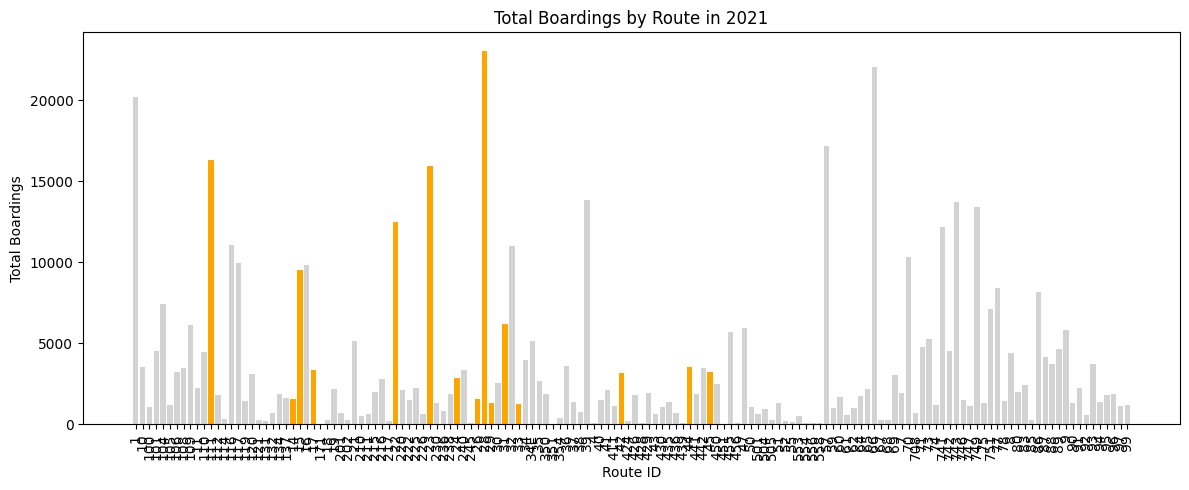

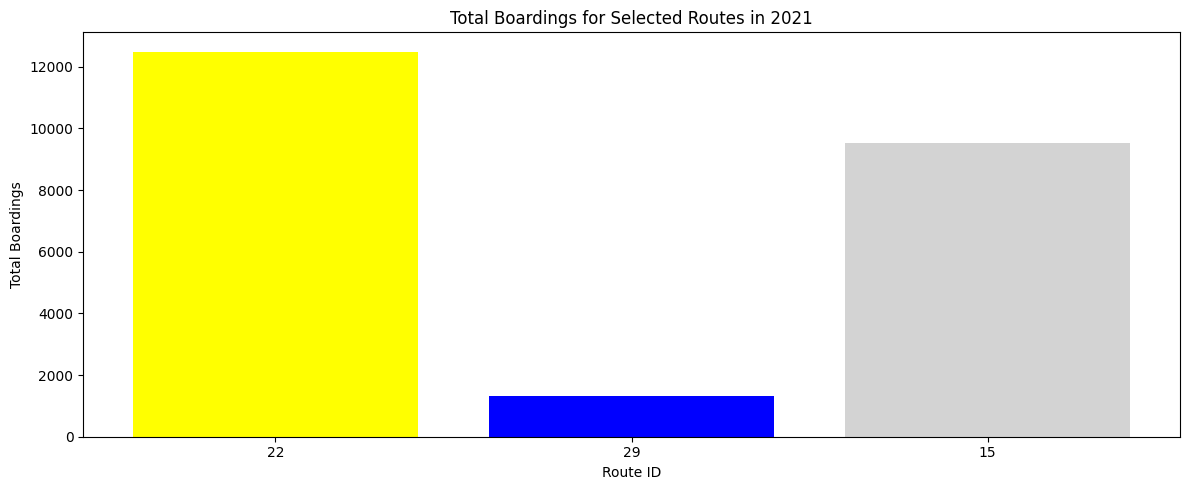

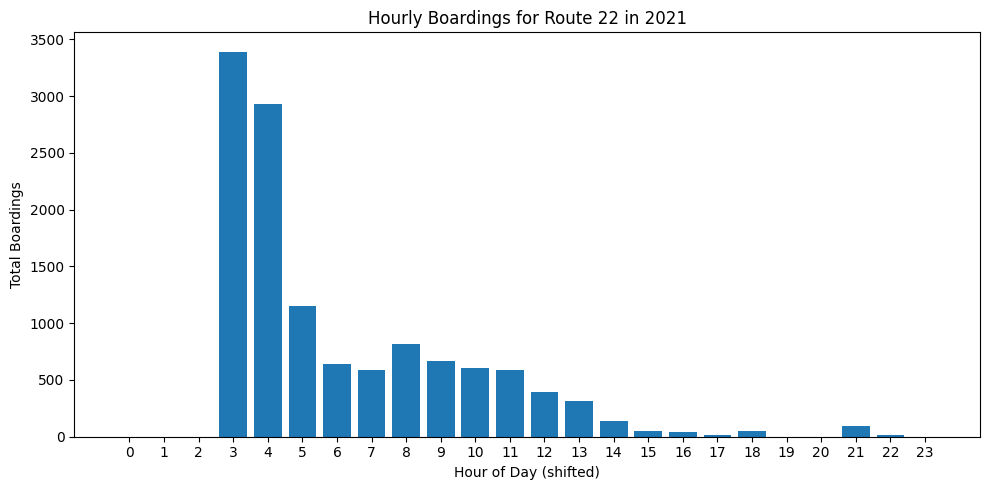

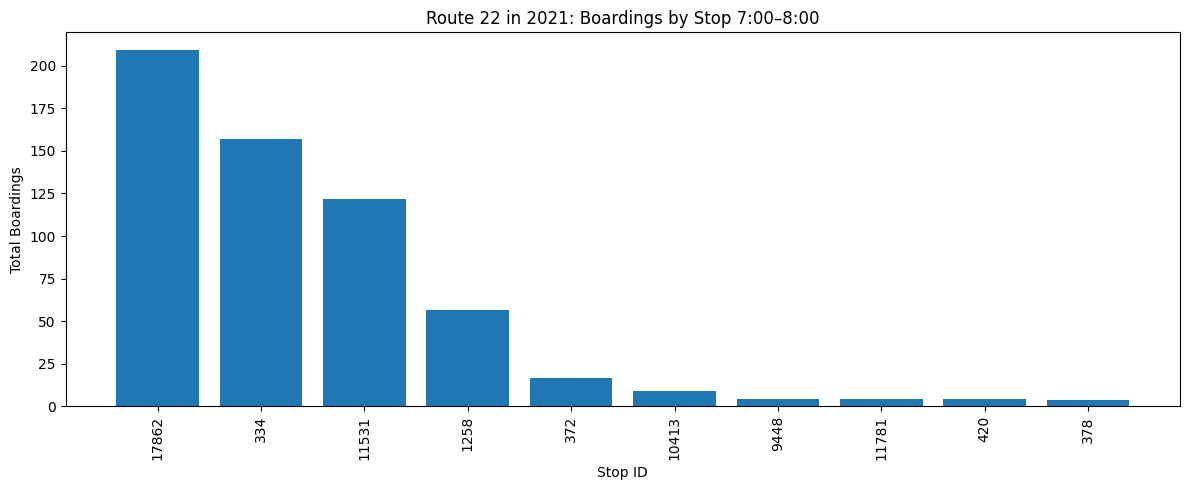

In [31]:
# 1) Default—all routes, with your target_routes in orange:
plot_boardings(df['2021'], year=2021)

# 2) Focus on routes [22,29,15], highlight lowest/highest:
plot_boardings(df['2021'], year=2021, focus_routes=[22,29,15])

# 3) Drill into one route:
plot_boardings(df['2021'], year=2021, route=22)

# 4) Stop breakdown for route 22 at 7 AM (shifted):
plot_boardings(df['2021'], year=2021, route=22, hour=7)


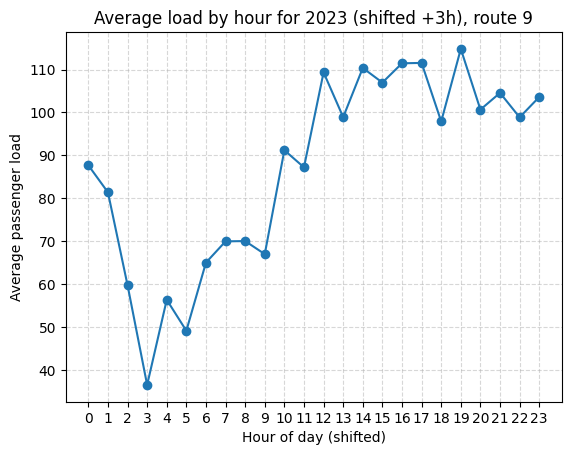

In [32]:
plot_hourly_average_load(hourly_load, "2023", route='9'
                        , stop=None)




I will now look at the main target routes and the ridership for it

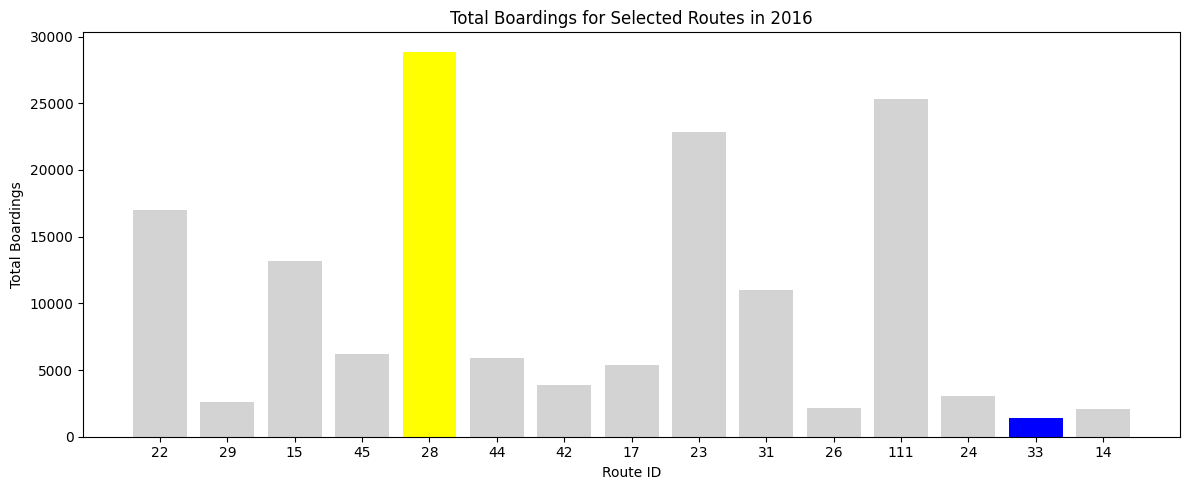

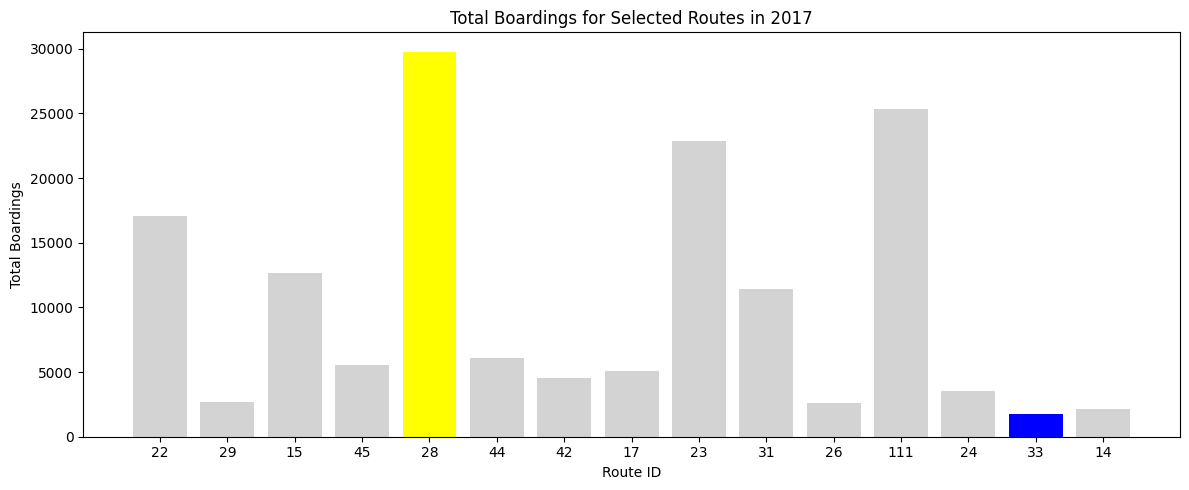

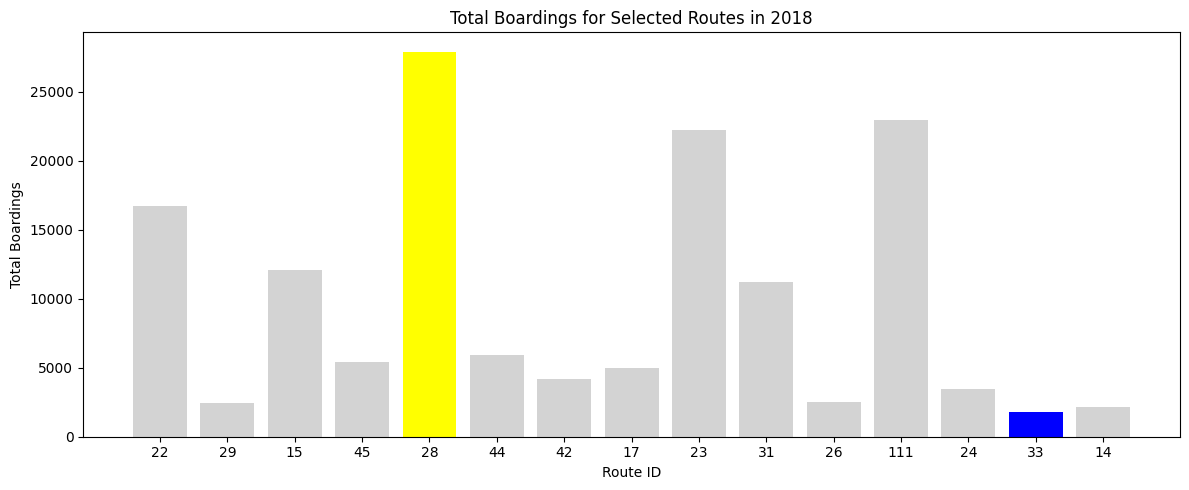

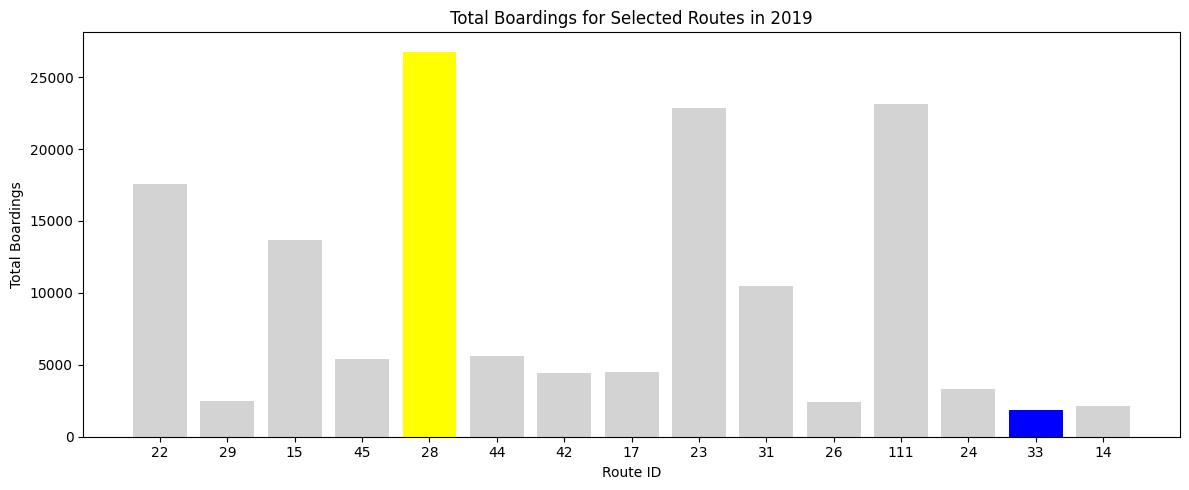

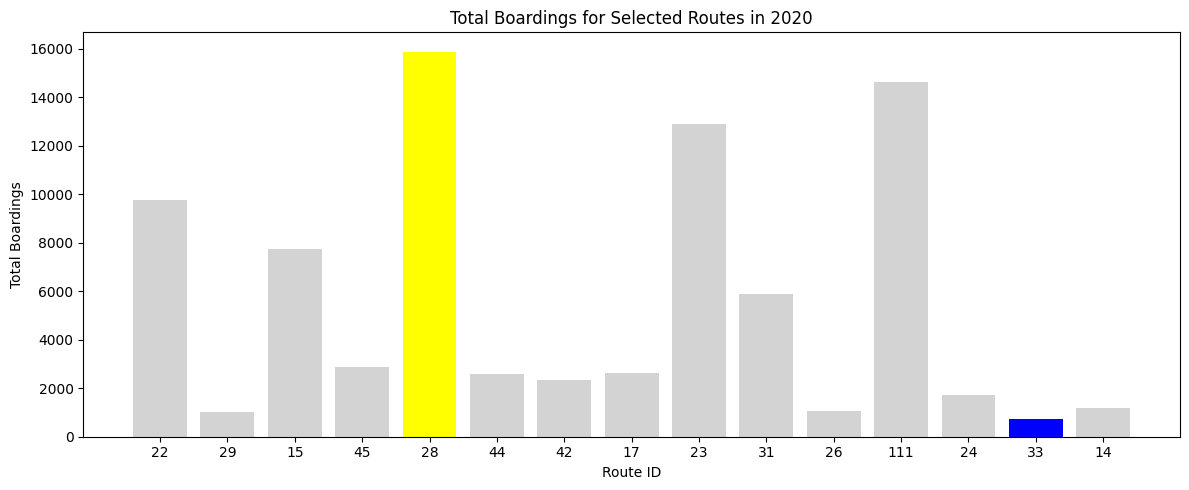

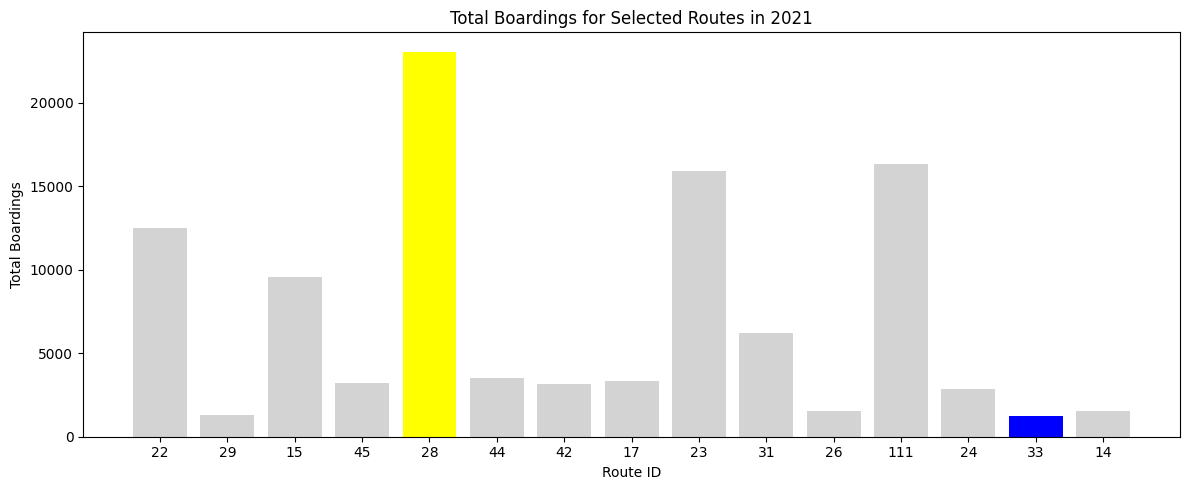

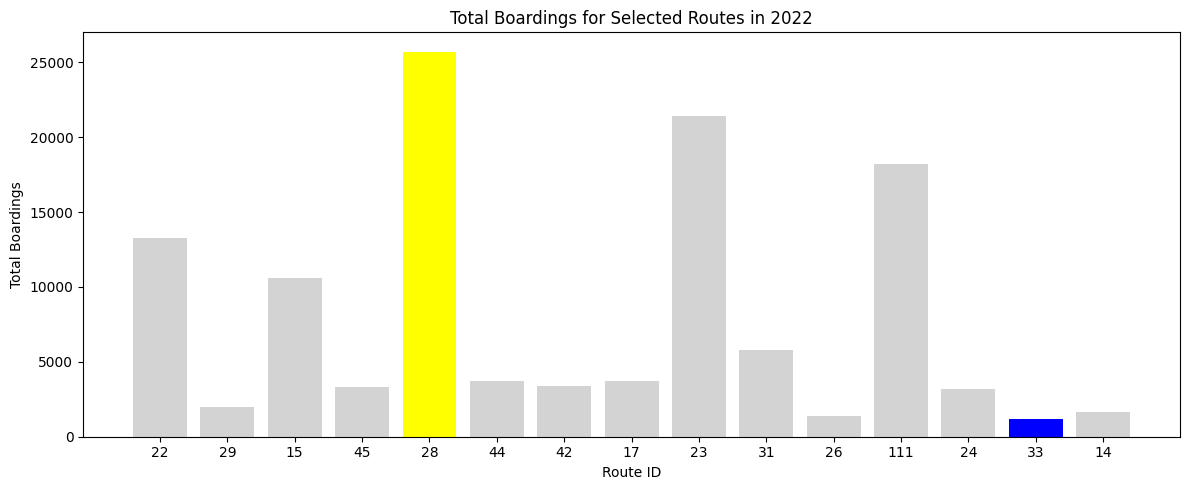

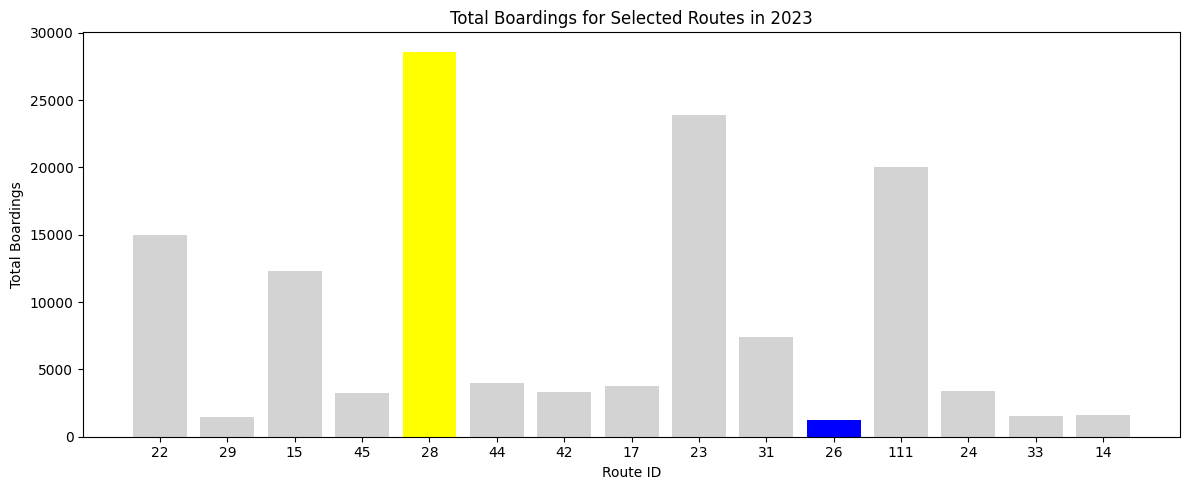

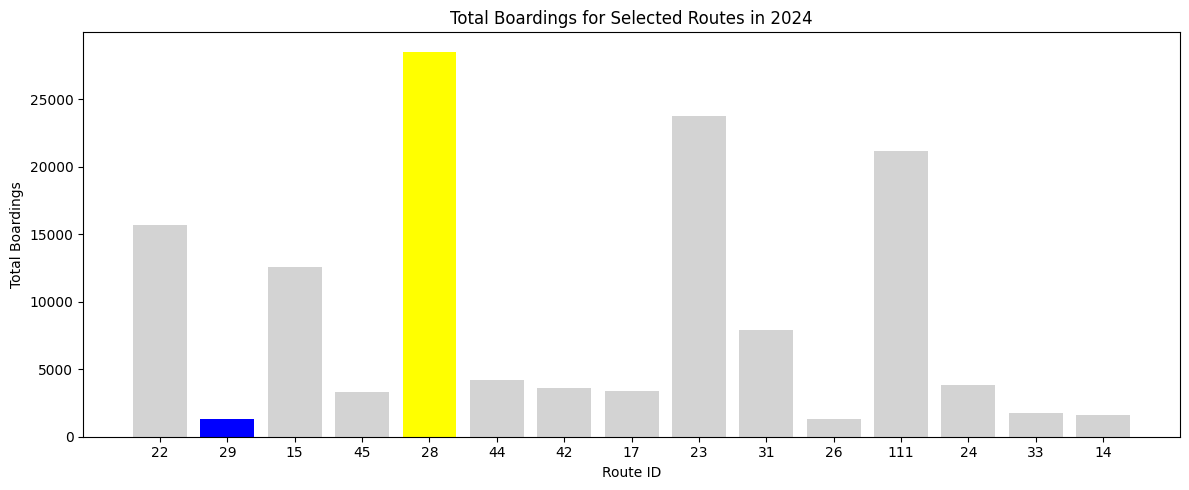

In [33]:
target_routes = [22,29,15,45,28,44,42,17,23,31,26,111,24,33,14]
years =['2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']

for years in years:
        plot_boardings(df[years], year=years, focus_routes=target_routes)